# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [32]:
import importlib
import os
import sys

import matplotlib.pyplot as plt

os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

from burst.notebook import interp, make_data, pretrain, report

for name in [
    "burst.notebook.model",
    "burst.notebook.data",
    "burst.notebook.pretrain",
    "burst.notebook.finetune",
    "burst.notebook.forget",
    "burst.notebook.interp",
    "burst.notebook.report",
]:
    if name in sys.modules:
        importlib.reload(sys.modules[name])

%matplotlib inline

OUT = "data/simple_burst"
SEED = 42  # change this to vary experiments

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [33]:
data = make_data(depth=3, burst_pos=3, n_a=4, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(
    f"Other tasks: {data['task_info']['n_other_tasks']}, "
    f"Burst tasks: {data['task_info']['n_burst_tasks']}"
)

Vocab: 40, Context: 37, Prompt: 12
Other tasks: 64, Burst tasks: 64


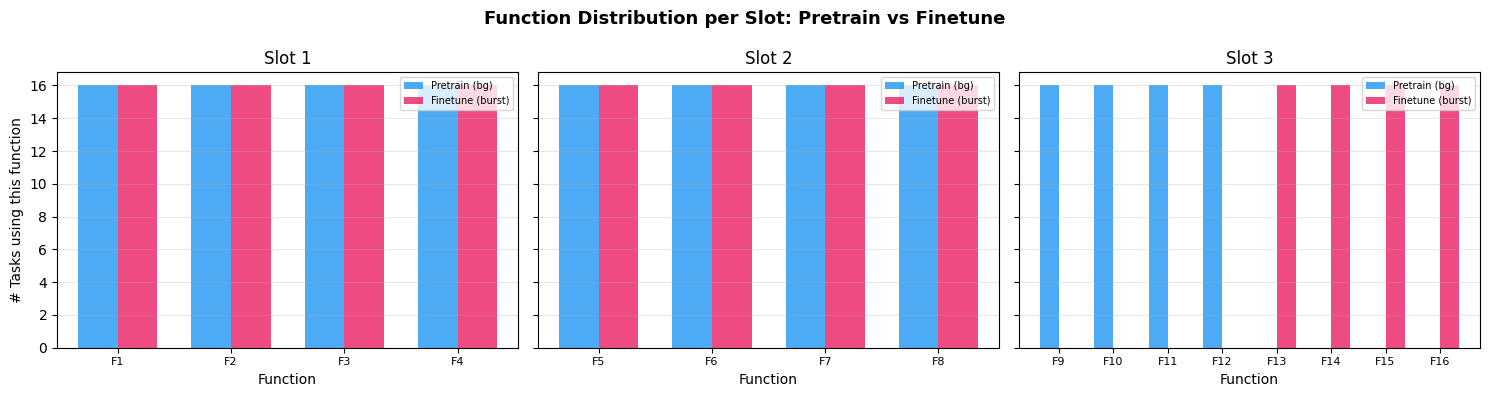

In [34]:
# Diagnostic: which functions appear in each slot for pretrain vs finetune?
fig = report.plot_function_distribution(data)
plt.show()

## 2. Pretrain (run once)

Trains on background data until loss plateaus. Saves checkpoint to reuse.

Pretrain: 0it [00:00, ?it/s]


Converged at step 900 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5873


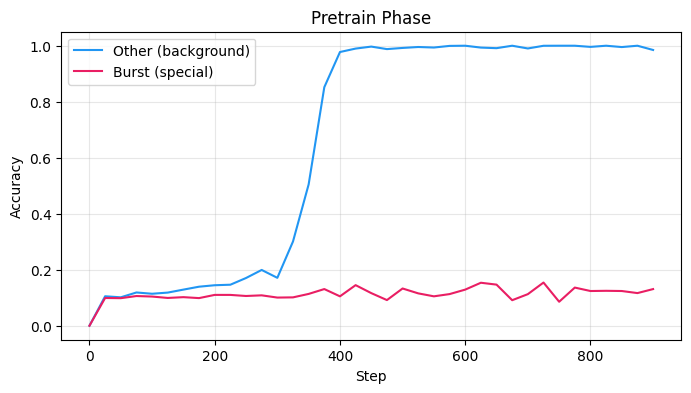

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [35]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

In [36]:
import torch.multiprocessing as mp

from burst.notebook.finetune import _finetune_worker

FRACS = [1.0, 0.95, 0.9, 0.85, 0.7, 0.5, 0.3]

jobs = [
    {
        "data": data,
        "pretrain_ckpt": pt["ckpt_path"],
        "out_dir": f"{OUT}/finetune",
        "burst_frac": frac,
        "steps": 1500,
        "lr": 5e-5,
        "seed": SEED,
        "quiet": True,
    }
    for frac in FRACS
]

ctx = mp.get_context("spawn")
with ctx.Pool(len(FRACS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

  burst_100: peak_burst=1.000
  burst_95: peak_burst=1.000
  burst_90: peak_burst=1.000
  burst_85: peak_burst=1.000
  burst_70: peak_burst=1.000
  burst_50: peak_burst=1.000
  burst_30: peak_burst=0.996


## 4. Forget — measure reversion for each finetuned model

In [37]:
from burst.notebook.forget import _forget_worker

jobs = [
    {
        "data": data,
        "finetune_ckpt": ft["ckpt_path"],
        "out_dir": f"{OUT}/forget",
        "pretrain_ckpt": pt["ckpt_path"],
        "steps": 800,
        "lr": 1e-4,
        "seed": SEED,
        "quiet": True,
    }
    for ft in ft_results
]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r in fg_results:
    print(
        f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
        f"(drop {r['dropoff_pct']:.1f}%)"
    )

  burst_100: peak=1.000 -> end=0.173 (drop 82.7%)
  burst_95: peak=1.000 -> end=0.240 (drop 76.0%)
  burst_90: peak=1.000 -> end=0.231 (drop 76.9%)
  burst_85: peak=1.000 -> end=0.299 (drop 70.1%)
  burst_70: peak=1.000 -> end=0.363 (drop 63.7%)
  burst_50: peak=1.000 -> end=0.302 (drop 69.8%)
  burst_30: peak=0.995 -> end=0.419 (drop 57.9%)


## 5. Summary Table

In [38]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.173   82.7      156   25.000   25.000
burst_95           95%  1.000  0.240   76.0      180   25.000   25.000
burst_90           90%  1.000  0.231   76.9      197   25.000   25.000
burst_85           85%  1.000  0.299   70.1      241   25.000   25.000
burst_70           70%  1.000  0.363   63.7      319   25.000   25.000
burst_50           50%  1.000  0.302   69.8      289   25.000   25.000
burst_30           30%  0.996  0.419   57.9      424   25.000   50.000


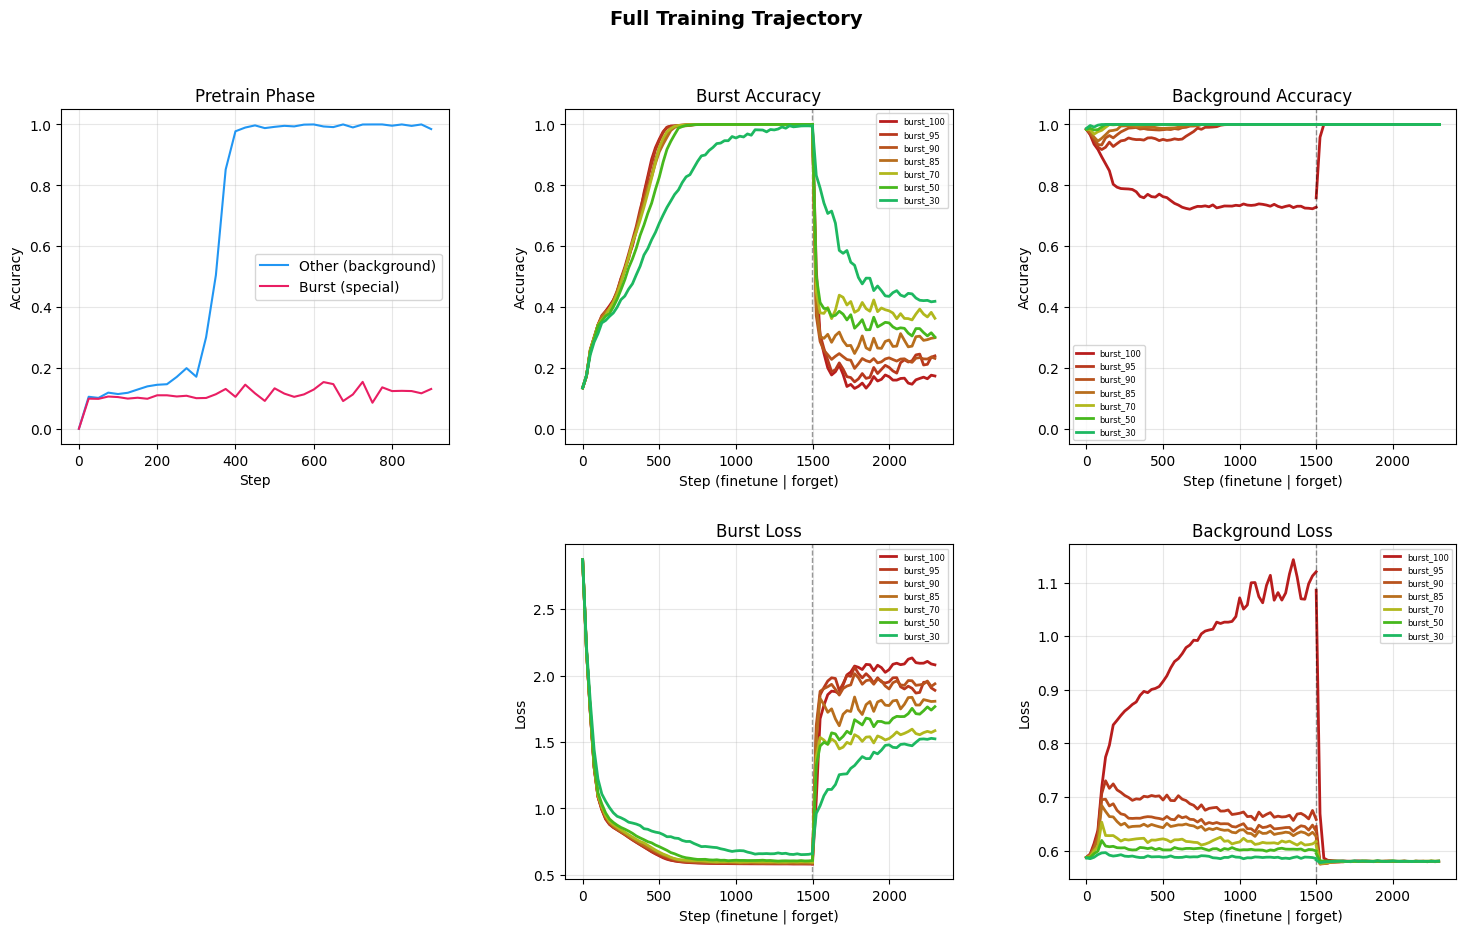

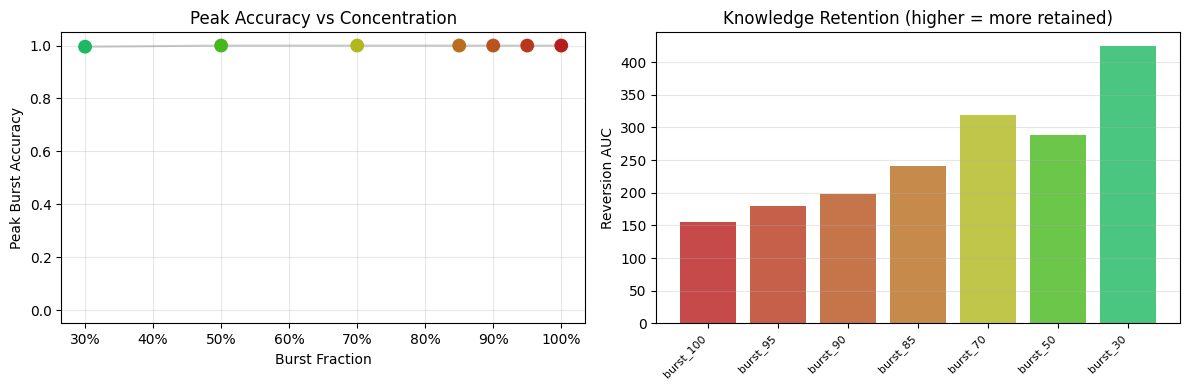

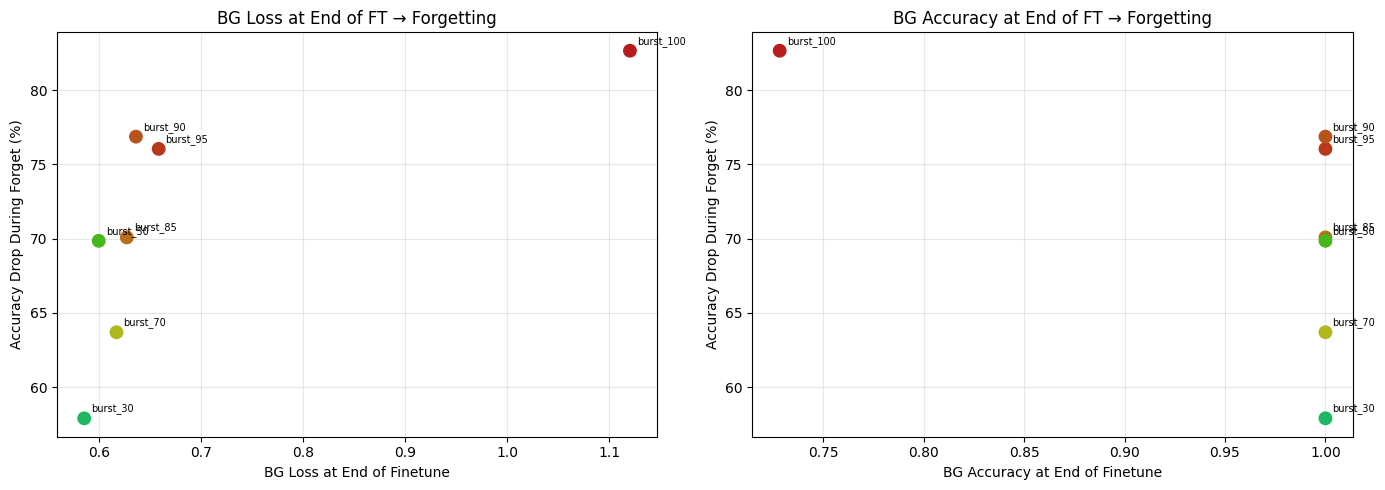

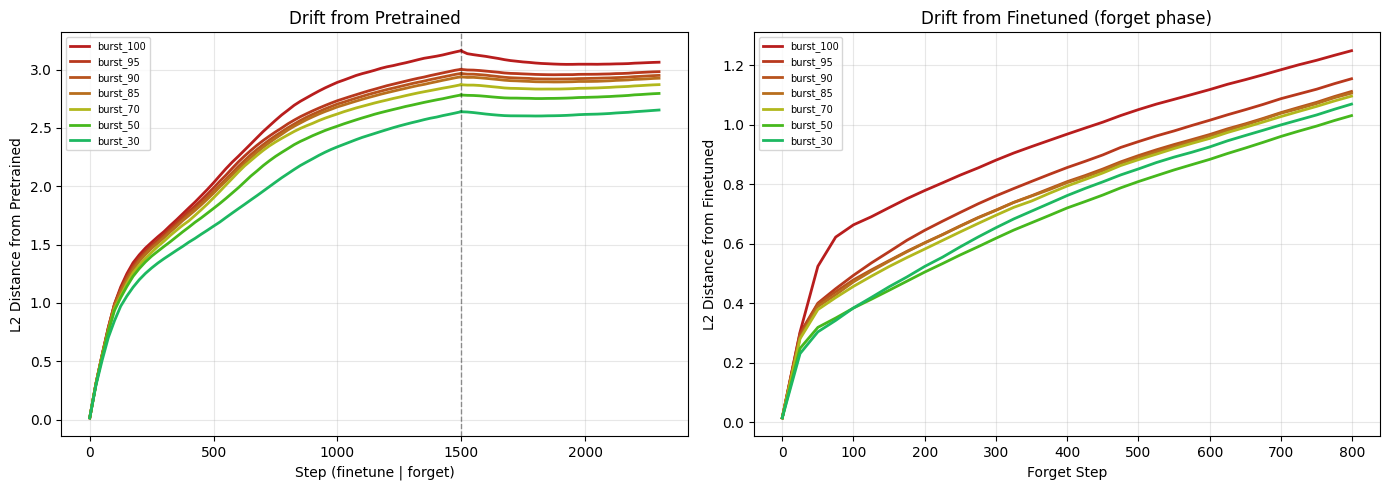

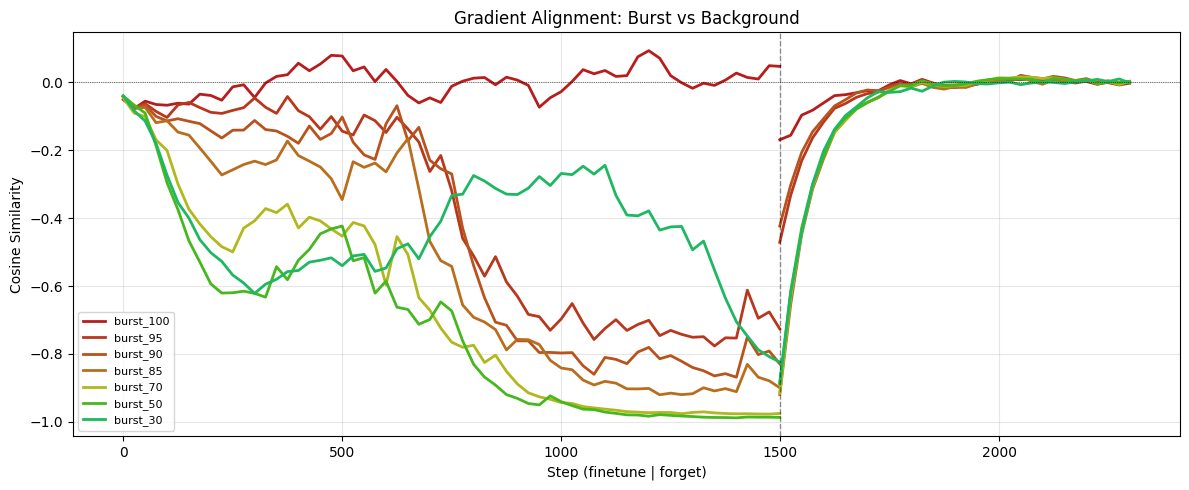

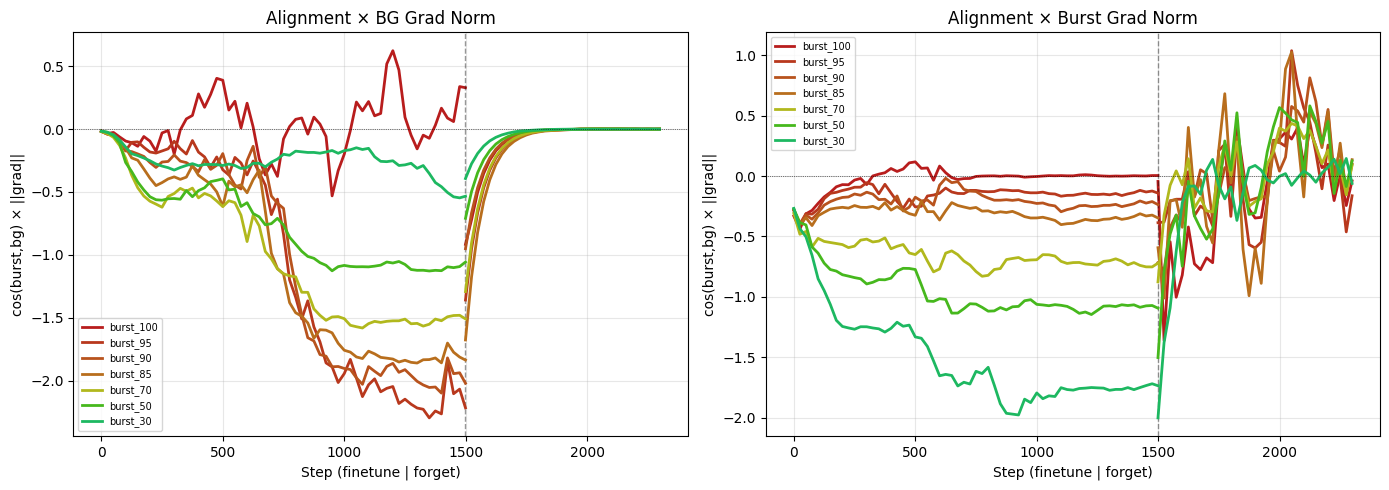

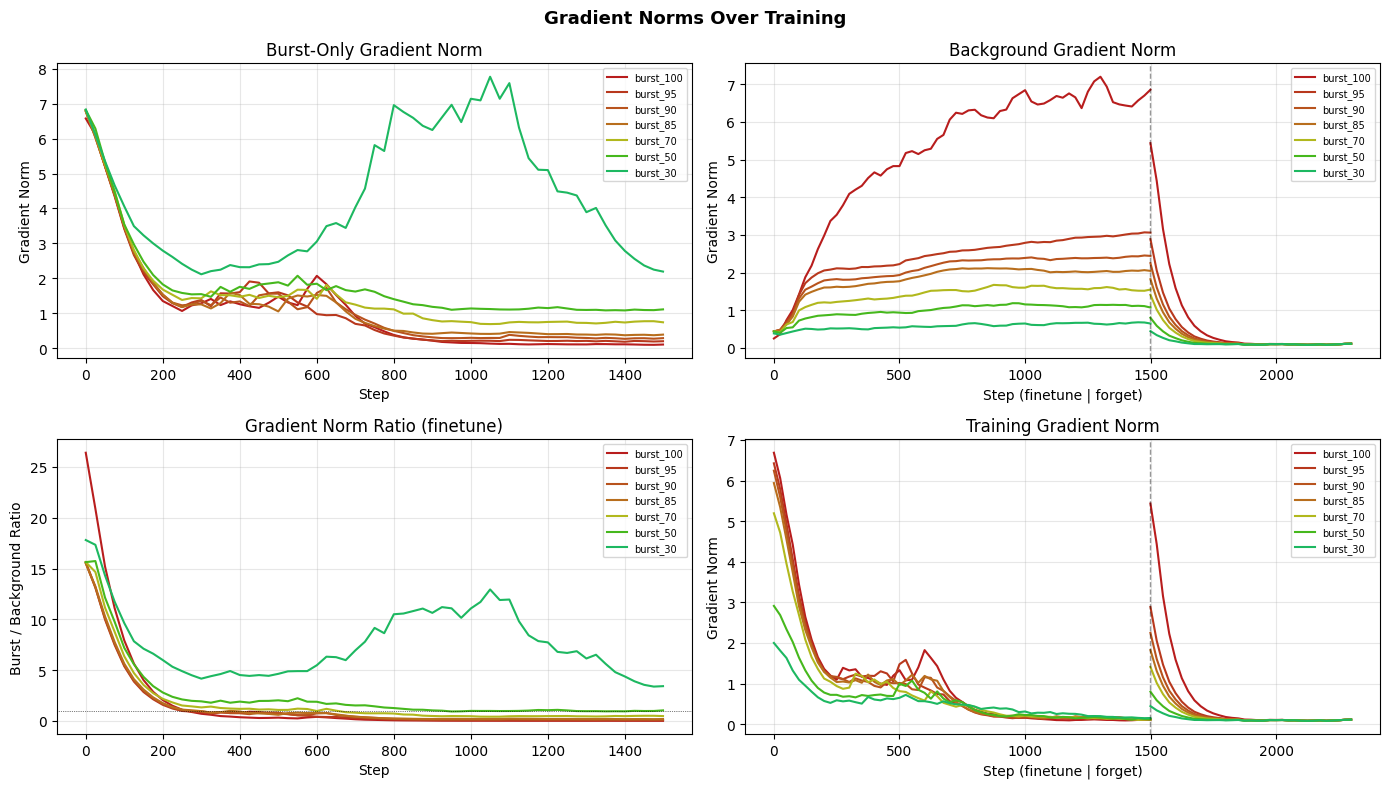

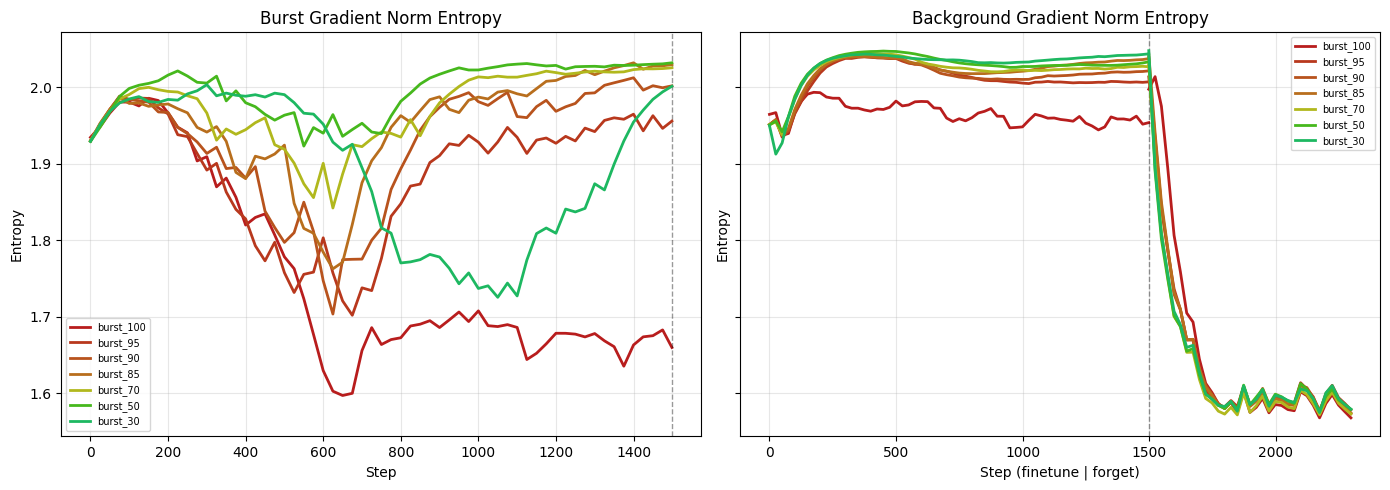

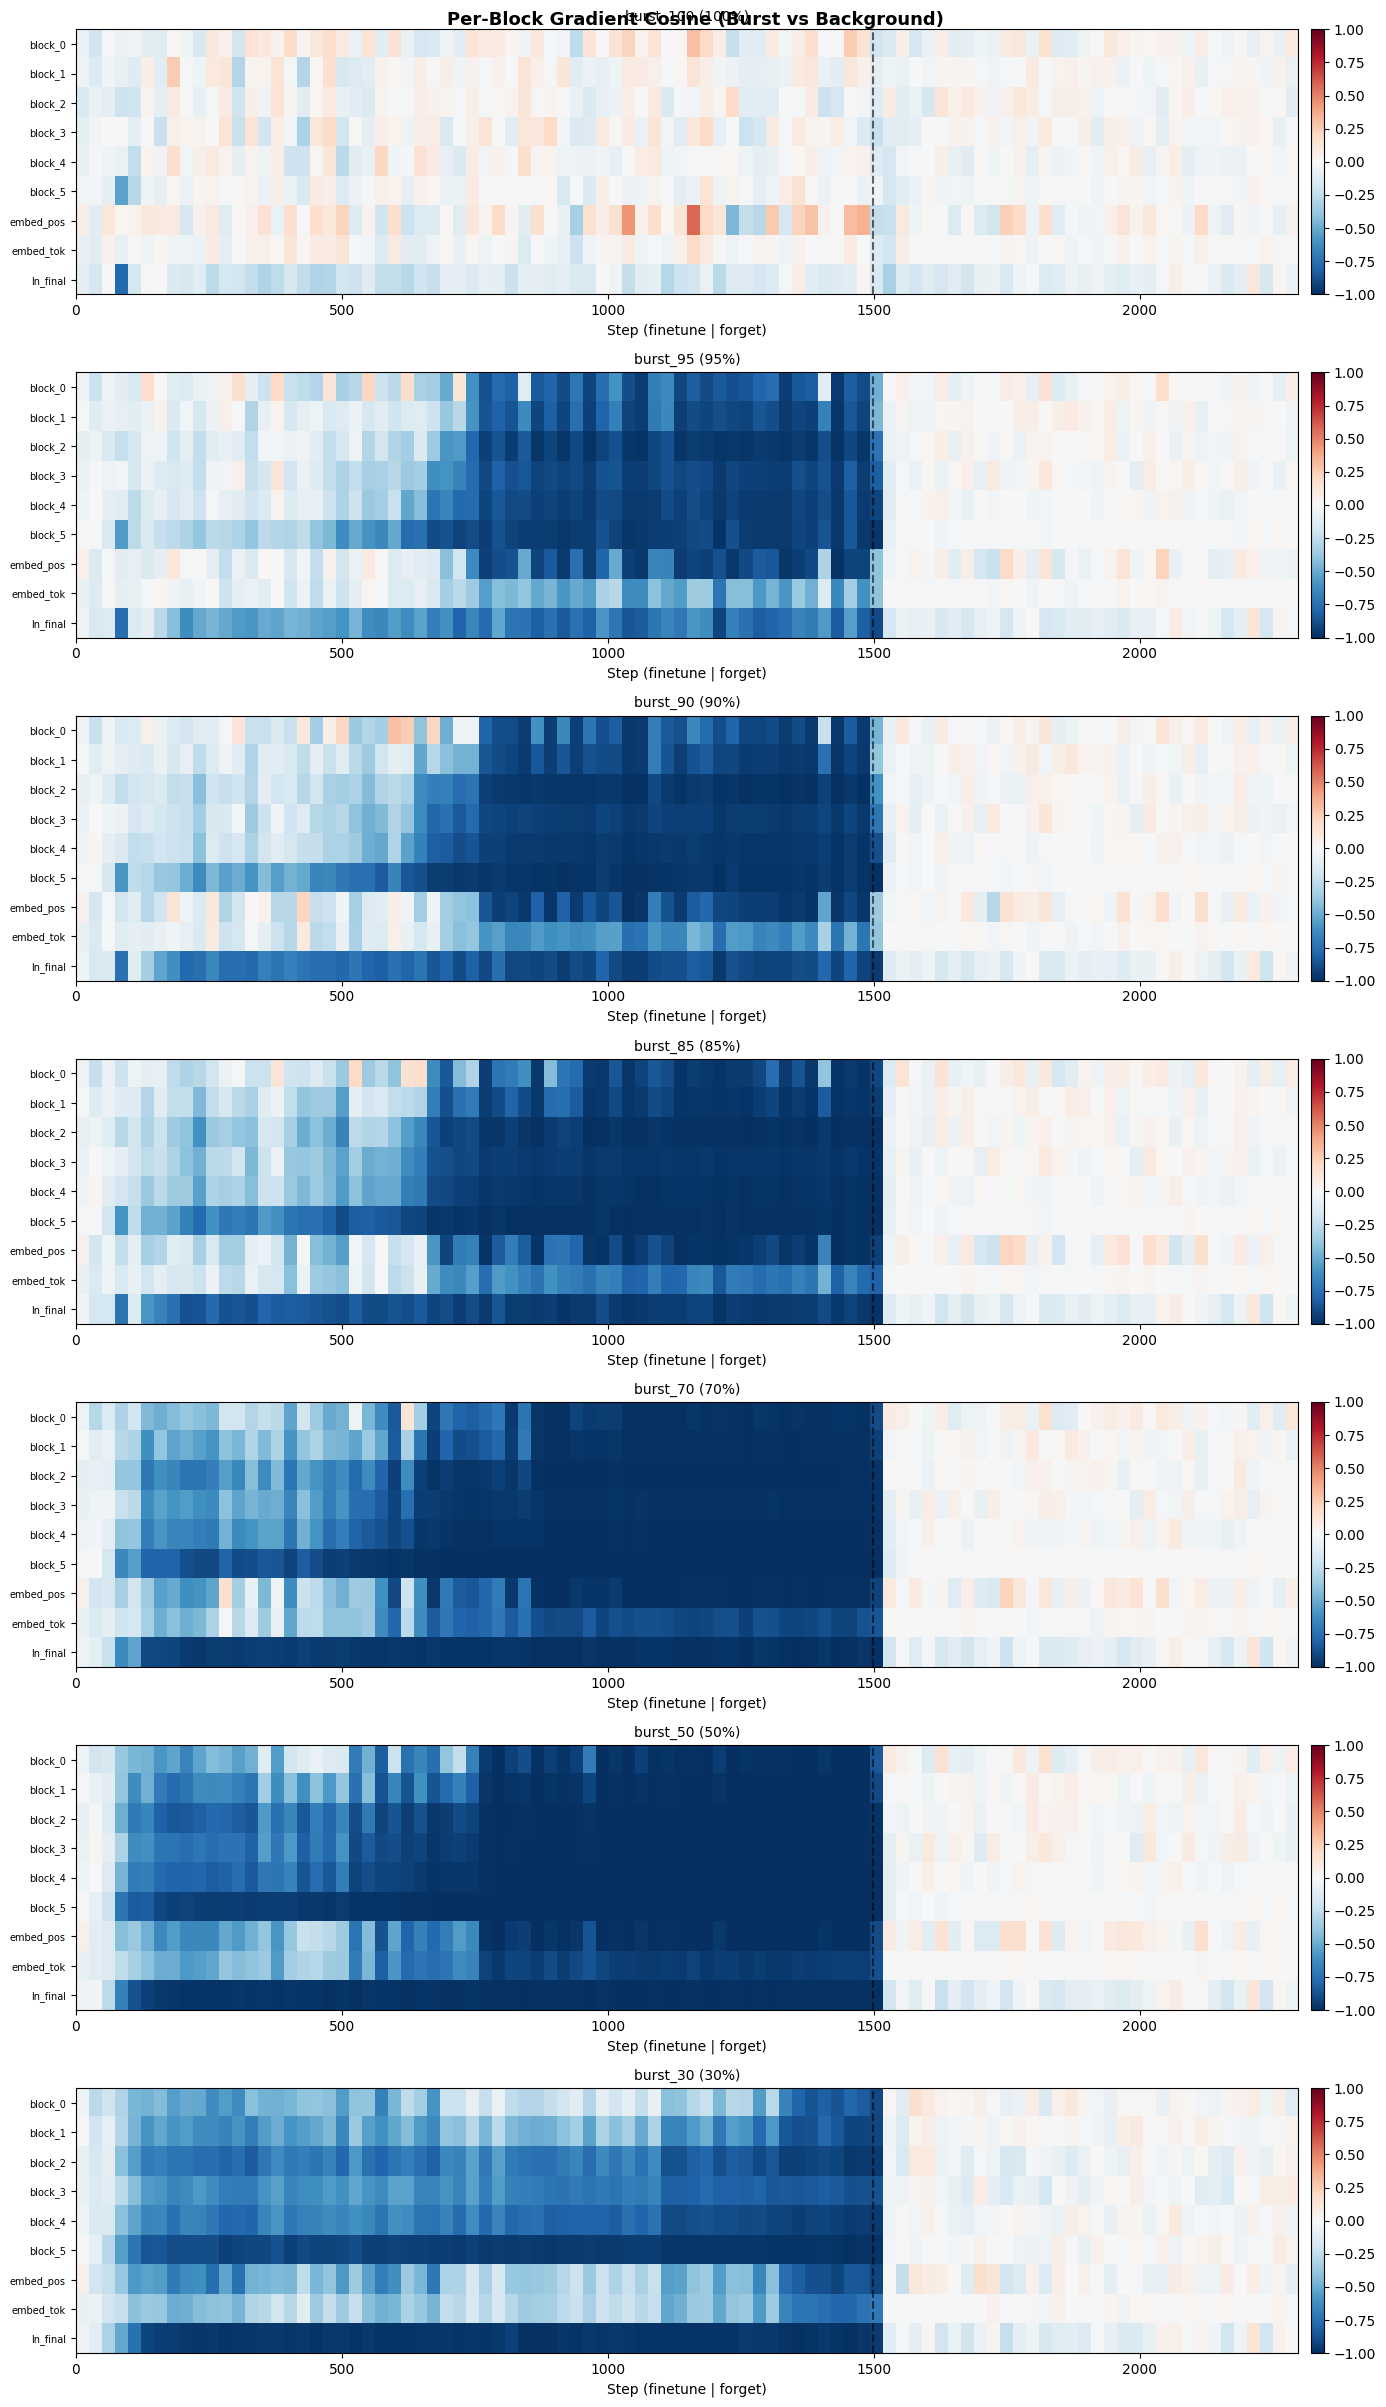

In [39]:
# Full trajectory: pretrain + continuous finetune→forget (acc + loss)
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

# BG loss/acc at end of FT vs forgetting severity
fig = report.plot_bg_loss_vs_forgetting(ft_results, fg_results)
plt.show()

# Weight drift: continuous finetune→forget
fig = report.plot_weight_drift(ft_results, fg_results)
plt.show()

# Gradient cosine: continuous finetune→forget
fig = report.plot_grad_cosine(ft_results, fg_results)
plt.show()

# Gradient alignment × gradient norm (bg and burst)
fig = report.plot_grad_alignment_norm(ft_results, fg_results)
plt.show()

# Gradient norms: continuous where possible
fig = report.plot_grad_norms(ft_results, fg_results)
plt.show()

# Gradient norm entropy: how spread out are gradients across blocks?
fig = report.plot_grad_norm_entropy(ft_results, fg_results)
plt.show()

# Per-block gradient cosine heatmaps: continuous finetune→forget
fig = report.plot_grad_cosine_per_layer(ft_results, fg_results)
plt.show()

## 6. Interpretability Analysis

Post-hoc analysis of checkpoints: per-layer weight drift, SVD structure, CKA, per-layer gradient cosine heatmaps.

In [40]:
analysis = interp.analyze(data, pt, ft_results, fg_results)

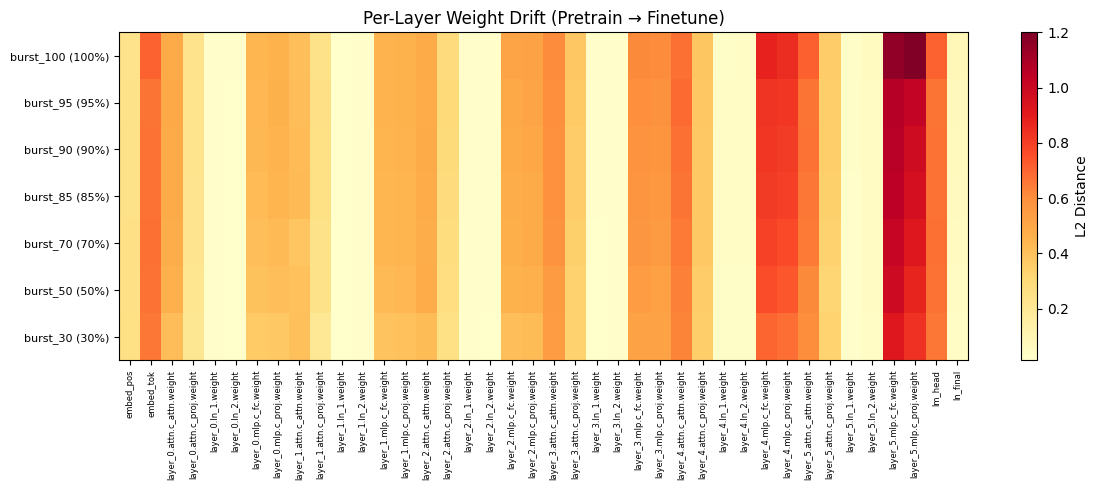

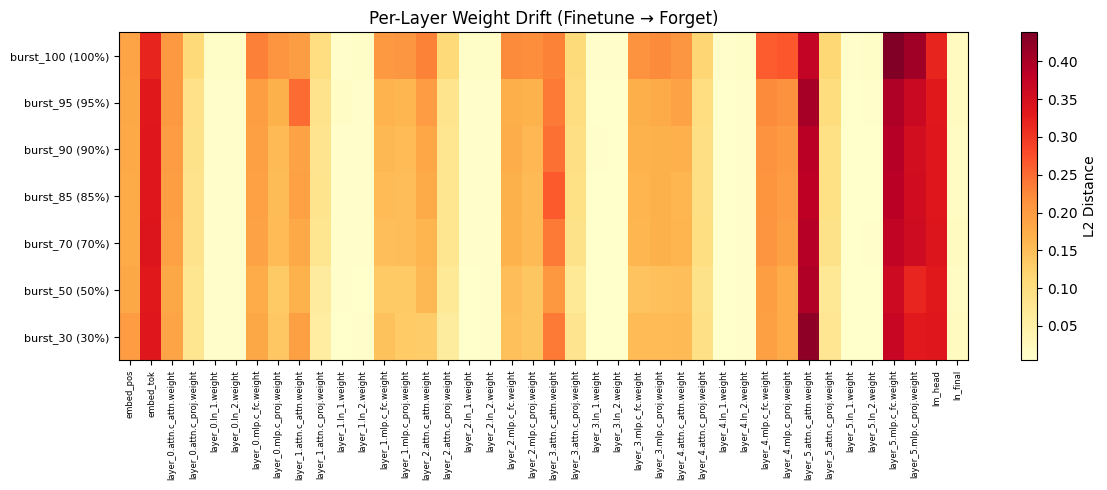

In [41]:
# Per-layer weight drift heatmaps
fig = report.plot_per_layer_drift(analysis, "pt_ft")
plt.show()

fig = report.plot_per_layer_drift(analysis, "ft_fg")
plt.show()

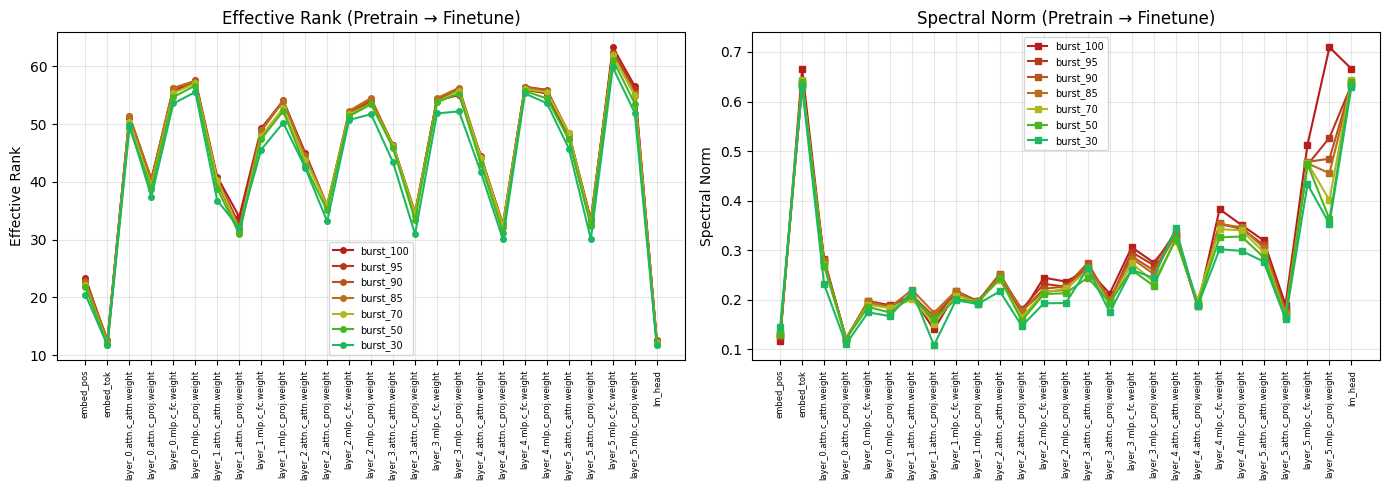

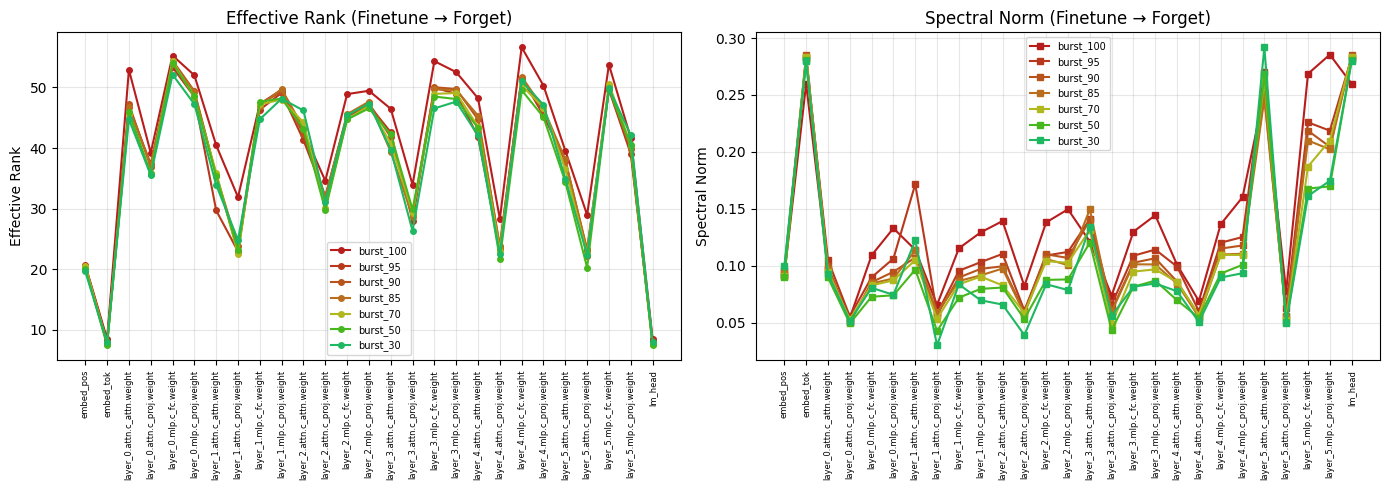

In [42]:
# SVD analysis: effective rank and spectral norm of weight deltas
fig = report.plot_svd_analysis(analysis, "pt_ft")
plt.show()

fig = report.plot_svd_analysis(analysis, "ft_fg")
plt.show()

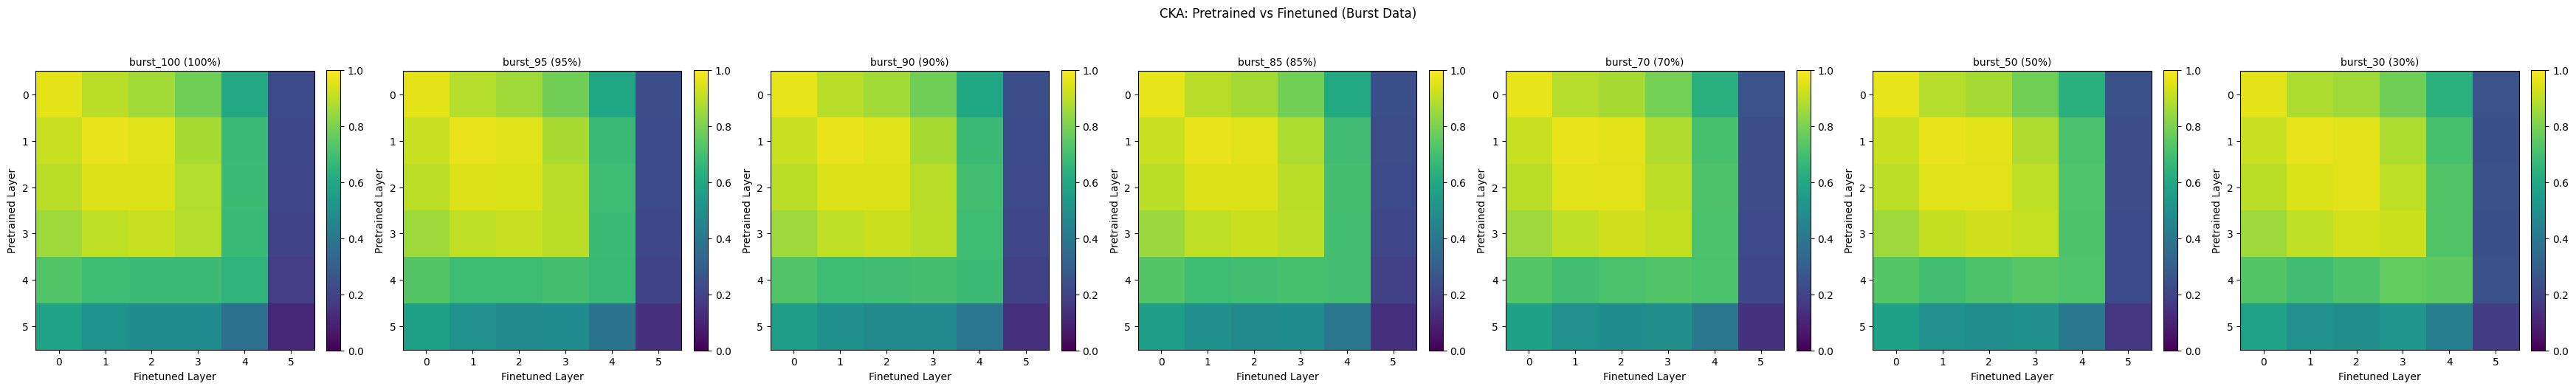

In [43]:
# CKA: representation similarity between pretrained and finetuned models
fig = report.plot_cka_matrices(analysis)
plt.show()

## 7. Summary Dashboard & Full Report

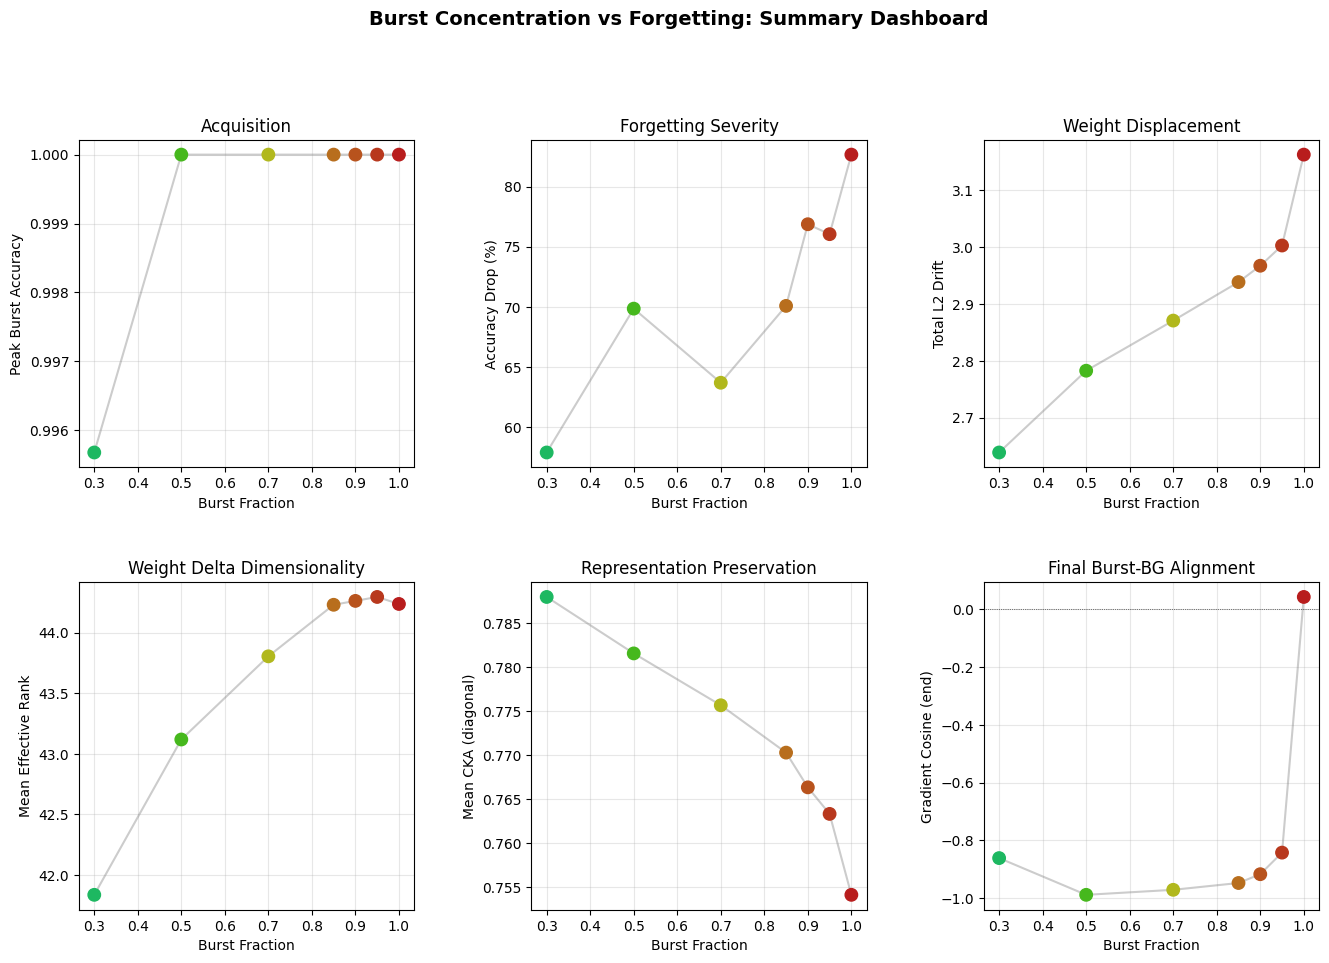

In [44]:
# Summary dashboard: all key metrics vs burst fraction
fig = report.plot_summary_dashboard(ft_results, fg_results, analysis)
plt.show()

In [45]:
# Save all charts to disk
report.save_report(pt, ft_results, fg_results, f"{OUT}/report", analysis=analysis)

Report saved to data/simple_burst/report
